# Proyecto NLP – Análisis de Sentimiento en Tweets (con lematización)

**Objetivo del TP (según consigna):**
- Entrenar y evaluar **al menos 2 modelos** con algoritmos vistos en clase usando el dataset grande (polaridad **0 y 4**).
- Probar esos modelos en el dataset chico (polaridad **0, 2, 4**) para medir generalización.
- Comparar performance con un modelo **pre‑entrenado** (ej. TextBlob).
- Incluir al menos una métrica vista en clase: **similitud coseno / PMI / etc.**

> Nota: el dataset grande no contiene neutrales (clase 2), por eso el entrenamiento es binario. La evaluación en el set 0/2/4 se reporta:
> 1) métrica principal en 0/4 filtrando neutrales,  
> 2) análisis aparte de cómo se comporta el modelo en neutrales.  
> Además, se incluye un **bonus** para obtener 3 clases vía umbrales de probabilidad.


In [2]:
# ===== 0. Imports y configuración =====
import re
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

import matplotlib.pyplot as plt

from textblob import TextBlob



## 0.1 Instalación de spaCy (una sola vez)

Corré esta celda solo si no tenés spaCy y el modelo en tu entorno.


In [3]:
# ===== 0.1 Instalar spaCy y modelo de inglés =====
!pip -q install spacy==3.7.2
!python -m spacy download en_core_web_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 8.8 MB/s eta 0:00:00 0:00:01
  Attempting uninstall: en-core-web-sm
    Found existing installation: en_core_web_sm 3.8.0
    Uninstalling en_core_web_sm-3.8.0:
      Successfully uninstalled en_core_web_sm-3.8.0
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


## 1. Carga de datos

Se asume que ambos archivos están en el mismo directorio que este notebook:

- `training.1600000.processed.noemoticon.csv`  (grande, 0/4)
- `testdata.manual.2009.06.14.csv`             (chico, 0/2/4)

**Formato columnas (consigna):**
0 polarity, 1 id, 2 date, 3 query, 4 user, 5 text


In [4]:
# ===== 1. Carga de datos =====
train_path = "training.1600000.processed.noemoticon.csv"
test_path  = "testdata.manual.2009.06.14.csv"

train_cols = ["polarity","id","date","query","user","text"]
test_cols  = ["polarity","id","date","query","user","text"]

train_df = pd.read_csv(train_path, encoding="latin-1", header=None, names=train_cols)
test_df  = pd.read_csv(test_path, encoding="latin-1", header=None, names=test_cols)

print(train_df.head())
print(test_df.head())

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


   polarity          id                          date     query  \
0         0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1         0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2         0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3         0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4         0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   

              user                                               text  
0  _TheSpecialOne_  @switchfoot http://twitpic.com/2y1zl - Awww, t...  
1    scotthamilton  is upset that he can't update his Facebook by ...  
2         mattycus  @Kenichan I dived many times for the ball. Man...  
3          ElleCTF    my whole body feels itchy and like its on fire   
4           Karoli  @nationwideclass no, it's not behaving at all....  
   polarity  id                          date    query      user  \
0         4   3  Mon May 11 03:17:40 UTC 2009  kindle2    tpryan   
1         4   4  Mon May 11 0

## 2. EDA rápido

- Distribución de clases  
- Largo de tweets  
- Muestras por clase


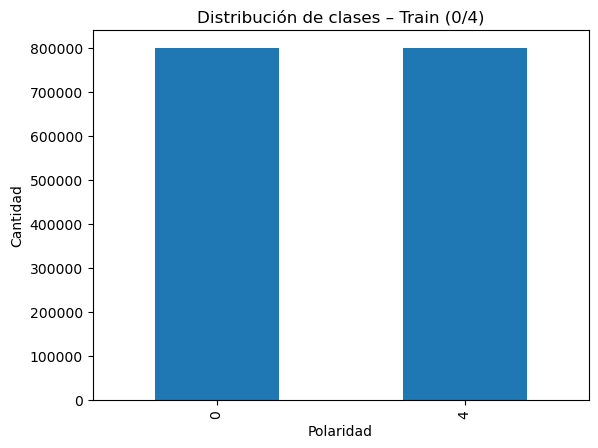

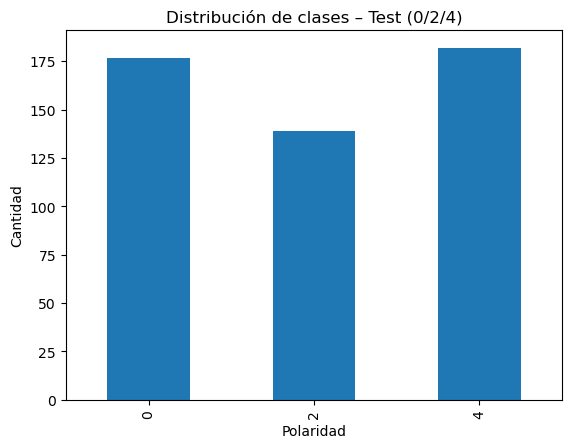

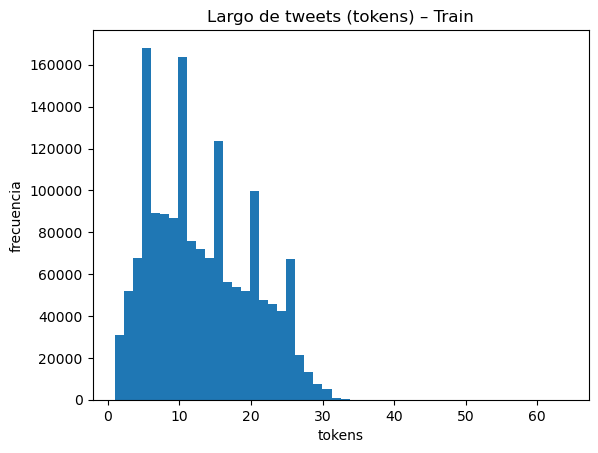

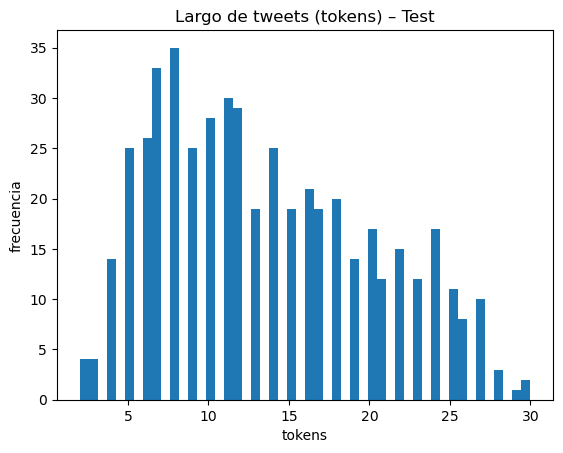

Ejemplos train negativo: ['@TheRealScarab PA system bugs are a bummer, sorry.  ', "oh daaamnnn! the firemen ball's on the 14th and i'll still be in Cannes  So many handsome men united 2gether, and i miss it! *out tonite*", "I don't want to be cold in April, but I am "]
Ejemplos train positivo: ['@miaakoch good luck in the concert ', 'will play JL. Be right back. ', '@chr15t14n  thanks.']


In [6]:
# ===== 2. EDA =====
def plot_class_distribution(df, title):
    counts = df["polarity"].value_counts().sort_index()
    plt.figure()
    counts.plot(kind="bar")
    plt.title(title)
    plt.xlabel("Polaridad")
    plt.ylabel("Cantidad")
    plt.show()

plot_class_distribution(train_df, "Distribución de clases – Train (0/4)")
plot_class_distribution(test_df, "Distribución de clases – Test (0/2/4)")

# Largo de tweets
train_df["len"] = train_df["text"].astype(str).apply(lambda x: len(x.split()))
test_df["len"] = test_df["text"].astype(str).apply(lambda x: len(x.split()))

plt.figure()
plt.hist(train_df["len"], bins=50)
plt.title("Largo de tweets (tokens) – Train")
plt.xlabel("tokens")
plt.ylabel("frecuencia")
plt.show()

plt.figure()
plt.hist(test_df["len"], bins=50)
plt.title("Largo de tweets (tokens) – Test")
plt.xlabel("tokens")
plt.ylabel("frecuencia")
plt.show()

# ejemplos
print("Ejemplos train negativo:", 
      train_df[train_df.polarity==0].text.sample(3, random_state=1).to_list())

print("Ejemplos train positivo:", 
      train_df[train_df.polarity==4].text.sample(3, random_state=1).to_list())

## 3. Preprocesamiento + Lematización

1) Limpieza básica (lowercase, URLs, menciones, etc.)  
2) **Lematización con spaCy** + eliminación de stopwords

Esto compacta vocabulario y suele mejorar generalización.


In [7]:
# ===== 3. Limpieza básica =====
url_re = re.compile(r"https?://\S+|www\.\S+")
mention_re = re.compile(r"@\w+")
hashtag_re = re.compile(r"#(\w+)")

def clean_tweet(text: str) -> str:
    text = str(text).lower()
    text = url_re.sub(" ", text)
    text = mention_re.sub(" ", text)
    text = hashtag_re.sub(r"\1", text)  # #happy -> happy
    text = re.sub(r"[^a-z\s']", " ", text)  # sólo letras y '
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["text_clean"] = train_df["text"].apply(clean_tweet)
test_df["text_clean"]  = test_df["text"].apply(clean_tweet)

train_df[["text","text_clean"]].head()


,text,text_clean
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww that's a bummer you shoulda got david car...
1,is upset that he can't update his Facebook by ...,is upset that he can't update his facebook by ...
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....",no it's not behaving at all i'm mad why am i h...


In [8]:
# ===== 3.1 Lematización eficiente =====
import spacy
from spacy.lang.en.stop_words import STOP_WORDS

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
nlp.max_length = 2_000_000

def lemmatize_texts(texts, batch_size=2000, n_process=2):
    lemmatized = []
    for doc in nlp.pipe(texts, batch_size=batch_size, n_process=n_process):
        tokens = [
            t.lemma_.lower()
            for t in doc
            if t.is_alpha and t.lemma_ != "-PRON-" and t.text.lower() not in STOP_WORDS
        ]
        lemmatized.append(" ".join(tokens))
    return lemmatized

train_df["text_lemma"] = lemmatize_texts(train_df["text_clean"].tolist(), n_process=2)
test_df["text_lemma"]  = lemmatize_texts(test_df["text_clean"].tolist(), n_process=2)

train_df[["text_clean","text_lemma"]].head()


,text_clean,text_lemma
0,awww that's a bummer you shoulda got david car...,awww bummer shoulda get david carr day d
1,is upset that he can't update his facebook by ...,upset update facebook texte cry result school ...
2,i dived many times for the ball managed to sav...,dive time ball manage save rest bound
3,my whole body feels itchy and like its on fire,body feel itchy like fire
4,no it's not behaving at all i'm mad why am i h...,behave mad


## 4. Preparación de splits (binario)

El train grande es binario (0 vs 4).  
Creamos un split train/valid interno.


In [9]:
# ===== 4. Split interno =====
X = train_df["text_lemma"]
y = train_df["polarity"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train interno:", X_train.shape, "Valid interno:", X_valid.shape)


Train interno: (1280000,) Valid interno: (320000,)


## 5. Vectorización y modelos

Entrenamos dos modelos binarios:
1. Logistic Regression + TF‑IDF
2. Multinomial Naive Bayes + TF‑IDF

Sensibilidad:
- unigramas (1,1)
- unigramas+bigramas (1,2)


In [10]:
# ===== 5. Entrenamiento modelos =====
def train_and_eval(model, ngram_range=(1,1), max_features=200000):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=ngram_range, max_features=max_features)),
        ("clf", model)
    ])
    pipe.fit(X_train, y_train)
    pred_valid = pipe.predict(X_valid)
    acc = accuracy_score(y_valid, pred_valid)
    f1  = f1_score(y_valid, pred_valid, average="weighted")
    return pipe, acc, f1

configs = [
    ("LR uni", LogisticRegression(max_iter=200, n_jobs=-1), (1,1)),
    ("LR bi",  LogisticRegression(max_iter=200, n_jobs=-1), (1,2)),
    ("NB uni", MultinomialNB(), (1,1)),
    ("NB bi",  MultinomialNB(), (1,2)),
]

results = []
models = {}

for name, model, ngrams in configs:
    pipe, acc, f1 = train_and_eval(model, ngram_range=ngrams)
    results.append((name, ngrams, acc, f1))
    models[name] = pipe
    print(name, "ngrams", ngrams, "acc", round(acc,4), "f1w", round(f1,4))

results_df = pd.DataFrame(results, columns=["modelo","ngrams","acc_valid","f1w_valid"])
results_df.sort_values("f1w_valid", ascending=False)


LR uni ngrams (1, 1) acc 0.7673 f1w 0.7671
LR bi ngrams (1, 2) acc 0.7794 f1w 0.7793
NB uni ngrams (1, 1) acc 0.7512 f1w 0.7512
NB bi ngrams (1, 2) acc 0.764 f1w 0.764


,modelo,ngrams,acc_valid,f1w_valid
1,LR bi,"(1, 2)",0.779375,0.779263
0,LR uni,"(1, 1)",0.767253,0.767094
3,NB bi,"(1, 2)",0.764009,0.764008
2,NB uni,"(1, 1)",0.751169,0.751155


## 6. Evaluación interna detallada (mejor modelo)

In [ ]:
# ===== 6. Mejor modelo interno =====
best_name = results_df.sort_values("f1w_valid", ascending=False).iloc[0]["modelo"]
best_model = models[best_name]
print("Mejor modelo:", best_name)

pred_valid = best_model.predict(X_valid)

print(classification_report(y_valid, pred_valid))
print("Confusion matrix:
", confusion_matrix(y_valid, pred_valid))


## 7. Test externo en dataset chico (0/2/4)

### 7.1 Métrica principal binaria (filtrando neutrales)
### 7.2 Análisis de neutrales


In [ ]:
# ===== 7. Test externo =====
X_test_all = test_df["text_lemma"]
y_test_all = test_df["polarity"]

# 7.1 Filtrar neutrales
mask_bin = y_test_all.isin([0,4])
X_test_bin = X_test_all[mask_bin]
y_test_bin = y_test_all[mask_bin]

pred_test_bin = best_model.predict(X_test_bin)

acc_test_bin = accuracy_score(y_test_bin, pred_test_bin)
f1_test_bin  = f1_score(y_test_bin, pred_test_bin, average="weighted")

print("Test binario (0/4) – acc:", round(acc_test_bin,4), "f1w:", round(f1_test_bin,4))
print(classification_report(y_test_bin, pred_test_bin))
print("Confusion matrix (test binario):
", confusion_matrix(y_test_bin, pred_test_bin))

# 7.2 neutrales
mask_neu = y_test_all == 2
X_test_neu = X_test_all[mask_neu]
pred_test_neu = best_model.predict(X_test_neu)

neu_to_0 = (pred_test_neu == 0).mean()
neu_to_4 = (pred_test_neu == 4).mean()

print("Neutrales (2) enviados a 0:", round(neu_to_0,3))
print("Neutrales (2) enviados a 4:", round(neu_to_4,3))


## 8. Bonus: pasar a 3 clases con umbrales de probabilidad

In [ ]:
# ===== 8. 3 clases por umbrales =====
if hasattr(best_model.named_steps["clf"], "predict_proba"):
    proba_pos = best_model.predict_proba(X_test_all)[:,1]
else:
    scores = best_model.decision_function(X_test_all)
    proba_pos = 1 / (1 + np.exp(-scores))

low_thr, high_thr = 0.4, 0.6

pred_3 = np.where(proba_pos > high_thr, 4,
          np.where(proba_pos < low_thr, 0, 2))

print("Reporte 3‑clases (con umbrales):")
print(classification_report(y_test_all, pred_3))
print("Confusion matrix 3‑clases:
", confusion_matrix(y_test_all, pred_3))


## 9. Baseline pre‑entrenado: TextBlob

In [ ]:
# ===== 9. TextBlob baseline =====
def textblob_predict_3(text):
    pol = TextBlob(text).sentiment.polarity
    if pol > 0.1:
        return 4
    elif pol < -0.1:
        return 0
    else:
        return 2

if TEXTBLOB_AVAILABLE:
    tb_pred = test_df["text_clean"].apply(textblob_predict_3).values
    print("TextBlob 3‑clases:")
    print(classification_report(y_test_all, tb_pred))
    print("Confusion matrix:
", confusion_matrix(y_test_all, tb_pred))

    # Comparación binaria filtrada
    tb_pred_bin = tb_pred[mask_bin]
    print("TextBlob binario (0/4) en test:")
    print(classification_report(y_test_bin, tb_pred_bin))
else:
    print("TextBlob no disponible.")


## 10. Métrica de clase: Similitud Coseno entre clases

In [ ]:
# ===== 10. Similitud coseno =====
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = best_model.named_steps["tfidf"]
X_test_vec = vectorizer.transform(X_test_all)

idx_pos = np.where(y_test_all.values == 4)[0]
idx_neg = np.where(y_test_all.values == 0)[0]
idx_neu = np.where(y_test_all.values == 2)[0]

def mean_cosine(idxs_a, idxs_b, n_sample=200):
    rng = np.random.default_rng(0)
    a = rng.choice(idxs_a, size=min(n_sample, len(idxs_a)), replace=False)
    b = rng.choice(idxs_b, size=min(n_sample, len(idxs_b)), replace=False)
    sim = cosine_similarity(X_test_vec[a], X_test_vec[b])
    return sim.mean()

cos_pp = mean_cosine(idx_pos, idx_pos)
cos_nn = mean_cosine(idx_neg, idx_neg)
cos_pn = mean_cosine(idx_pos, idx_neg)
cos_neu_pos = mean_cosine(idx_neu, idx_pos)
cos_neu_neg = mean_cosine(idx_neu, idx_neg)

print("Cos(pos,pos):", round(cos_pp,4))
print("Cos(neg,neg):", round(cos_nn,4))
print("Cos(pos,neg):", round(cos_pn,4))
print("Cos(neu,pos):", round(cos_neu_pos,4))
print("Cos(neu,neg):", round(cos_neu_neg,4))


## 11. Conclusiones (completar)

- Mejor modelo y por qué  
- Efecto de bigramas  
- Generalización externa  
- Comportamiento en neutrales  
- TextBlob vs modelos propios  
- Separabilidad con coseno
